# **Lecture 22: Applications in Astrophysics - N-Body Simulations**

**Unit:** 4 (Applications in Astrophysics)

**Topic:** Gravity, Equations of Motion, and the Realistic 2-Body Problem

---

## **1. The Philosophy of N-Body Simulations**

An N-body simulation is a numerical approximation of the evolution of a system of bodies (like stars, planets, or dark matter particles) that interact with each other through a physical force—usually gravity.

While we can solve the 2-Body problem exactly using Kepler's laws and analytical algebra, the **3-Body problem (and anything $N > 2$) has no general exact analytical solution** (a fact proven by Henri Poincaré in 1887). To predict the future of the Solar System, a star cluster, or a colliding galaxy, we *must* use computers to integrate the equations of motion step-by-step.


## **2. The Equations of Motion**

Newton's Law of Universal Gravitation states that the force exerted on body $i$ by body $j$ is:
$$\vec{F}_{ij} = G \frac{m_i m_j}{|\vec{r}_{ij}|^3} \vec{r}_{ij}$$

Where $\vec{r}_{ij} = \vec{r}_j - \vec{r}_i$ is the vector pointing from body $i$ to body $j$.

Using Newton's Second Law ($\vec{F} = m\vec{a}$), the acceleration of body $i$ due to the gravitational pull of *all* other $(N-1)$ bodies in the system is:
$$\frac{d^2\vec{r}_i}{dt^2} = \sum_{j \neq i}^{N} G \frac{m_j}{|\vec{r}_j - \vec{r}_i|^3} (\vec{r}_j - \vec{r}_i)$$

This is a **System of 2nd-Order Ordinary Differential Equations (ODEs)**. Just as we did for the Wave Equation and the Simple Harmonic Oscillator, we must break this down into a system of 1st-Order ODEs to feed it into a Python solver.

## **3. The Secret Weapon: Astronomical Units (Normalization)**

If we simulate the Earth and Sun in SI units, we have to deal with:
* $G = 6.67 \times 10^{-11}$
* $M_{sun} = 2.0 \times 10^{30}$ kg
* $r = 1.5 \times 10^{11}$ m

Multiplying $10^{-11}$ by $10^{30}$ and dividing by $(10^{11})^2$ creates massive **floating-point truncation and round-off errors** (as discussed in Lecture 11). 

**The Professional Solution:** We change our units.
* **Mass:** Solar Masses ($M_\odot$) $\implies M_{sun} = 1.0$
* **Distance:** Astronomical Units (AU) $\implies r_{earth} = 1.0$
* **Time:** Years (yr) $\implies P_{earth} = 1.0$

If we plug these units into Kepler's Third Law ($P^2 = \frac{4\pi^2}{GM} a^3$), we get:
$$1^2 = \frac{4\pi^2}{G \cdot 1} 1^3 \implies \mathbf{G = 4\pi^2}$$

By using $G = 4\pi^2$, all our numbers stay between $0$ and $10$, keeping our computational precision absolutely perfect!

## **4. Python Implementation: The Realistic Earth-Sun Model**
Let's write a vectorized 2-Body simulator using `scipy.integrate.solve_ivp`.

Integrating orbital equations...
Simulation complete!


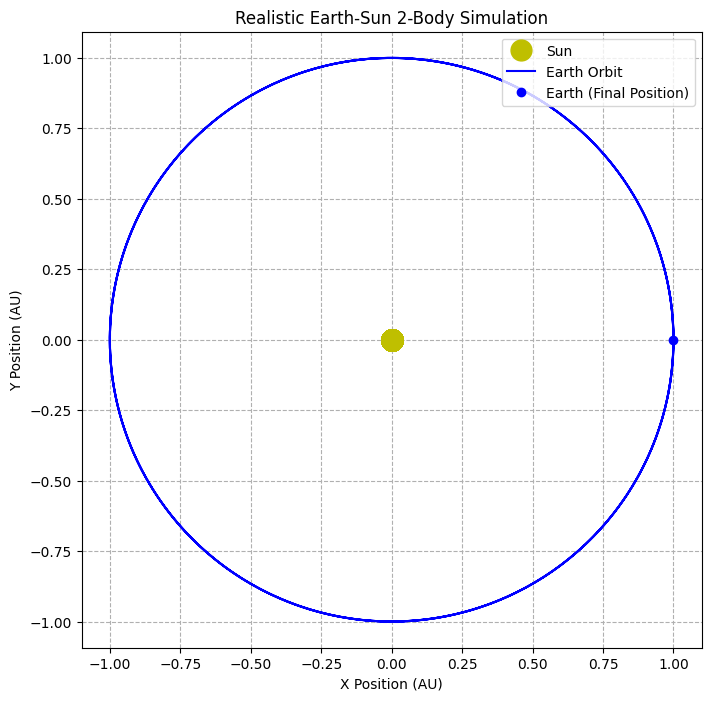

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Physical Constants (in Astronomical Units)
G = 4 * np.pi**2
M_sun = 1.0
M_earth = 3.003e-6  # Earth is approx 3 millionths of a Solar Mass

# 2. The Method of Lines (Derivatives Function)
def two_body_equations(t, y):
    """
    State vector y contains 8 variables:
    [x_sun, y_sun, x_earth, y_earth, vx_sun, vy_sun, vx_earth, vy_earth]
    """
    x1, y1, x2, y2, vx1, vy1, vx2, vy2 = y
    
    # Distance between Sun (1) and Earth (2)
    dx = x2 - x1
    dy = y2 - y1
    r_cubed = (dx**2 + dy**2)**1.5
    
    # Derivatives of position are just the velocities
    dx1_dt = vx1
    dy1_dt = vy1
    dx2_dt = vx2
    dy2_dt = vy2
    
    # Derivatives of velocities are the gravitational accelerations
    # Acceleration of Sun (pulled by Earth)
    dvx1_dt = G * M_earth * dx / r_cubed
    dvy1_dt = G * M_earth * dy / r_cubed
    
    # Acceleration of Earth (pulled by Sun)
    dvx2_dt = -G * M_sun * dx / r_cubed
    dvy2_dt = -G * M_sun * dy / r_cubed
    
    return [dx1_dt, dy1_dt, dx2_dt, dy2_dt, dvx1_dt, dvy1_dt, dvx2_dt, dvy2_dt]

# 3. Initial Conditions
# Sun at rest at the origin
sun_pos = [0.0, 0.0]
sun_vel = [0.0, 0.0]

# Earth at 1 AU on the x-axis
earth_pos = [1.0, 0.0]
# To maintain a circular orbit, v = sqrt(GM/r). Since G=4pi^2, M=1, r=1, v = 2*pi.
# It moves purely in the y-direction initially.
earth_vel = [0.0, 2 * np.pi] 

# Combine into single state vector y0
y0 = sun_pos + earth_pos + sun_vel + earth_vel

# 4. Run the Simulation
t_span = (0, 3.0) # Simulate for 3 Earth Years
t_eval = np.linspace(0, 3.0, 1000) # 1000 data points for smooth plotting

print("Integrating orbital equations...")
solution = solve_ivp(two_body_equations, t_span, y0, method='RK45', t_eval=t_eval, rtol=1e-8, atol=1e-8)
print("Simulation complete!")

# 5. Data Extraction and Visualization
x_sun, y_sun, x_earth, y_earth = solution.y[0], solution.y[1], solution.y[2], solution.y[3]

plt.figure(figsize=(8, 8))
plt.plot(x_sun, y_sun, 'yo', markersize=15, label="Sun")
plt.plot(x_earth, y_earth, 'b-', label="Earth Orbit")
plt.plot(x_earth[-1], y_earth[-1], 'bo', markersize=6, label="Earth (Final Position)")

plt.title("Realistic Earth-Sun 2-Body Simulation")
plt.xlabel("X Position (AU)")
plt.ylabel("Y Position (AU)")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--')
plt.axis('equal') # Ensure the circle doesn't look like an ellipse due to screen stretching
plt.show()


## **5. Student Exercises**

### **Exercise 1: The Heavy Jupiter Perturbation (The 3-Body Problem)**
Our current simulation solves the exact 2-Body problem. Now, let's make it a 3-Body problem by adding a gas giant.

**Task:** 
1. Modify the state vector `y` to hold 12 variables (positions and velocities for Sun, Earth, and Jupiter).
2. Add Jupiter's mass ($M_{jup} \approx 0.001 M_\odot$).
3. Place Jupiter at 5.2 AU on the x-axis, with an initial circular velocity of $v = \sqrt{G M_\odot / 5.2}$ in the y-direction.
4. Update the gravitational acceleration formulas. The Earth is now pulled by BOTH the Sun and Jupiter. Jupiter is pulled by the Sun and the Earth. 
5. Run the simulation for 12 years (one full Jupiter orbit). Does the Earth's orbit remain perfectly circular? Plot the results to see the perturbation.

---

### **Exercise 2: Euler's Catastrophe (Energy Conservation)**
In the `solve_ivp` function above, we used `method='RK45'`. This is a highly accurate Runge-Kutta solver. 

If we instead used a simple first-order **Euler Method** (like we did in Lecture 13), the Earth would slowly spiral into the Sun or fly away into space, even with tiny time steps. This is because Euler and standard RK4 are not **Symplectic**—they do not strictly conserve the geometric phase space (energy and angular momentum) of the system over long periods.

In the next lecture, we will build a custom **Leapfrog Integrator**—a symplectic algorithm specifically designed for N-Body orbital mechanics that perfectly conserves energy over billions of years.

Integrating 3-body orbital equations...
Simulation complete!


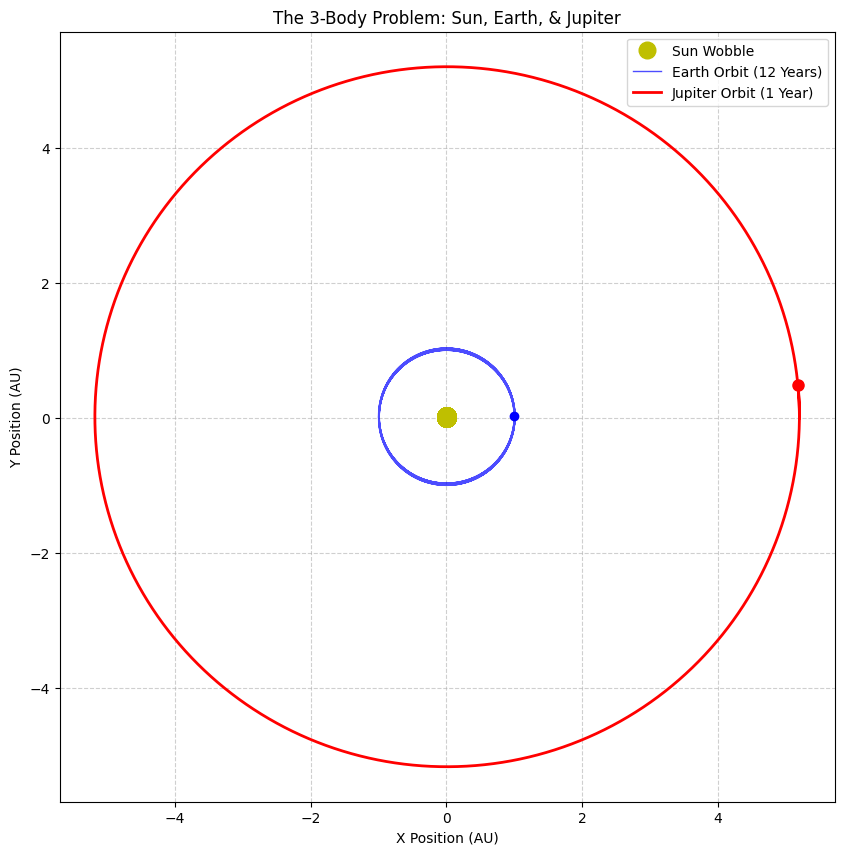

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Physical Constants (in Astronomical Units)
G = 4 * np.pi**2
M_sun = 1.0
M_earth = 3.003e-6  
M_jup = 0.001       # Jupiter is approx 1/1000th of a solar mass

# 2. The 3-Body Equations of Motion
def three_body_equations(t, y):
    """
    State vector y now contains 12 variables:
    [x1, y1, x2, y2, x3, y3, vx1, vy1, vx2, vy2, vx3, vy3]
    Index 1: Sun, Index 2: Earth, Index 3: Jupiter
    """
    x1, y1, x2, y2, x3, y3, vx1, vy1, vx2, vy2, vx3, vy3 = y
    
    # Distance components between bodies
    dx12 = x2 - x1
    dy12 = y2 - y1
    r12_cubed = (dx12**2 + dy12**2)**1.5  # Sun to Earth
    
    dx13 = x3 - x1
    dy13 = y3 - y1
    r13_cubed = (dx13**2 + dy13**2)**1.5  # Sun to Jupiter
    
    dx23 = x3 - x2
    dy23 = y3 - y2
    r23_cubed = (dx23**2 + dy23**2)**1.5  # Earth to Jupiter
    
    # Position derivatives (velocities)
    dx1_dt, dy1_dt = vx1, vy1
    dx2_dt, dy2_dt = vx2, vy2
    dx3_dt, dy3_dt = vx3, vy3
    
    # Velocity derivatives (accelerations via Newton's Law of Gravity)
    # Sun is pulled by Earth AND Jupiter
    dvx1_dt = G * M_earth * dx12 / r12_cubed + G * M_jup * dx13 / r13_cubed
    dvy1_dt = G * M_earth * dy12 / r12_cubed + G * M_jup * dy13 / r13_cubed
    
    # Earth is pulled by Sun AND Jupiter
    dvx2_dt = -G * M_sun * dx12 / r12_cubed + G * M_jup * dx23 / r23_cubed
    dvy2_dt = -G * M_sun * dy12 / r12_cubed + G * M_jup * dy23 / r23_cubed
    
    # Jupiter is pulled by Sun AND Earth
    dvx3_dt = -G * M_sun * dx13 / r13_cubed - G * M_earth * dx23 / r23_cubed
    dvy3_dt = -G * M_sun * dy13 / r13_cubed - G * M_earth * dy23 / r23_cubed
    
    return [dx1_dt, dy1_dt, dx2_dt, dy2_dt, dx3_dt, dy3_dt, 
            dvx1_dt, dvy1_dt, dvx2_dt, dvy2_dt, dvx3_dt, dvy3_dt]

# 3. Initial Conditions
sun_pos = [0.0, 0.0]
sun_vel = [0.0, 0.0]

earth_pos = [1.0, 0.0]
earth_vel = [0.0, 2 * np.pi] 

# Jupiter at 5.2 AU. Circular velocity v = sqrt(GM/r)
jup_pos = [5.2, 0.0]
jup_vel = [0.0, np.sqrt(G * M_sun / 5.2)]

# Combine into a single state vector y0
y0 = sun_pos + earth_pos + jup_pos + sun_vel + earth_vel + jup_vel

# 4. Run the Simulation for 12 Years
t_span = (0, 12.0) 
t_eval = np.linspace(0, 12.0, 5000) # Increased resolution for 12 years

print("Integrating 3-body orbital equations...")
solution = solve_ivp(three_body_equations, t_span, y0, method='RK45', t_eval=t_eval, rtol=1e-9, atol=1e-9)
print("Simulation complete!")

# 5. Extract and Visualize
x_sun, y_sun = solution.y[0], solution.y[1]
x_earth, y_earth = solution.y[2], solution.y[3]
x_jup, y_jup = solution.y[4], solution.y[5]

plt.figure(figsize=(10, 10))

# Plot orbits
plt.plot(x_sun, y_sun, 'yo', markersize=12, label="Sun Wobble")
plt.plot(x_earth, y_earth, 'b-', lw=1, alpha=0.7, label="Earth Orbit (12 Years)")
plt.plot(x_jup, y_jup, 'r-', lw=2, label="Jupiter Orbit (1 Year)")

# Plot final positions
plt.plot(x_earth[-1], y_earth[-1], 'bo', markersize=6)
plt.plot(x_jup[-1], y_jup[-1], 'ro', markersize=8)

plt.title("The 3-Body Problem: Sun, Earth, & Jupiter")
plt.xlabel("X Position (AU)")
plt.ylabel("Y Position (AU)")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal') 
plt.show()

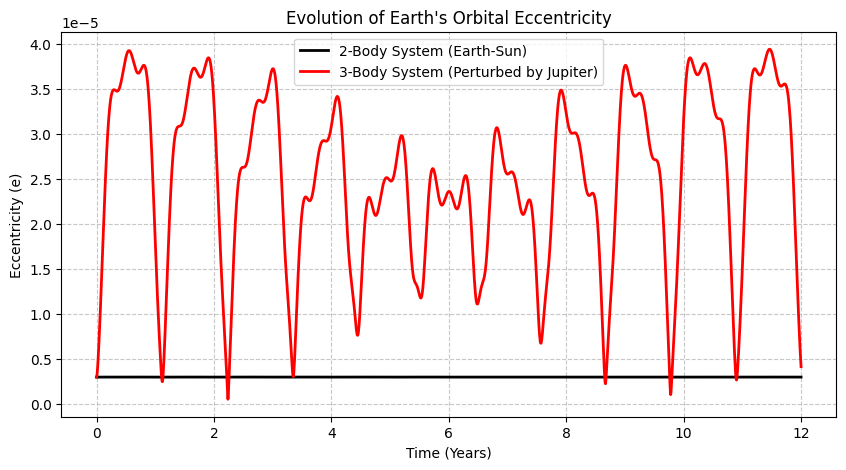

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- 1. Physical Constants ---
G = 4 * np.pi**2
M_sun = 1.0
M_earth = 3.003e-6  
M_jup = 0.001       

# --- 2. Equations of Motion ---
def two_body(t, y):
    x1, y1, x2, y2, vx1, vy1, vx2, vy2 = y
    dx, dy = x2 - x1, y2 - y1
    r3 = (dx**2 + dy**2)**1.5
    
    dvx1 = G * M_earth * dx / r3
    dvy1 = G * M_earth * dy / r3
    dvx2 = -G * M_sun * dx / r3
    dvy2 = -G * M_sun * dy / r3
    return [vx1, vy1, vx2, vy2, dvx1, dvy1, dvx2, dvy2]

def three_body(t, y):
    x1, y1, x2, y2, x3, y3, vx1, vy1, vx2, vy2, vx3, vy3 = y
    
    dx12, dy12 = x2 - x1, y2 - y1
    r12_3 = (dx12**2 + dy12**2)**1.5
    dx13, dy13 = x3 - x1, y3 - y1
    r13_3 = (dx13**2 + dy13**2)**1.5
    dx23, dy23 = x3 - x2, y3 - y2
    r23_3 = (dx23**2 + dy23**2)**1.5
    
    dvx1 = G * M_earth * dx12 / r12_3 + G * M_jup * dx13 / r13_3
    dvy1 = G * M_earth * dy12 / r12_3 + G * M_jup * dy13 / r13_3
    dvx2 = -G * M_sun * dx12 / r12_3 + G * M_jup * dx23 / r23_3
    dvy2 = -G * M_sun * dy12 / r12_3 + G * M_jup * dy23 / r23_3
    dvx3 = -G * M_sun * dx13 / r13_3 - G * M_earth * dx23 / r23_3
    dvy3 = -G * M_sun * dy13 / r13_3 - G * M_earth * dy23 / r23_3
    return [vx1, vy1, vx2, vy2, vx3, vy3, dvx1, dvy1, dvx2, dvy2, dvx3, dvy3]

# --- 3. Initial Conditions ---
y0_2body = [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 2*np.pi]
y0_3body = [0.0, 0.0, 1.0, 0.0, 5.2, 0.0, 0.0, 0.0, 0.0, 2*np.pi, 0.0, np.sqrt(G*M_sun/5.2)]

# --- 4. Run Simulations (12 Years) ---
t_span = (0, 12.0)
t_eval = np.linspace(0, 12.0, 2000)

sol_2body = solve_ivp(two_body, t_span, y0_2body, method='RK45', t_eval=t_eval, rtol=1e-9, atol=1e-9)
sol_3body = solve_ivp(three_body, t_span, y0_3body, method='RK45', t_eval=t_eval, rtol=1e-9, atol=1e-9)

# --- 5. Eccentricity Calculation Function ---
def calculate_eccentricity(solution, is_3body=False):
    # Extract Sun and Earth states
    x_sun, y_sun = solution.y[0], solution.y[1]
    x_earth, y_earth = solution.y[2], solution.y[3]
    
    if is_3body:
        vx_sun, vy_sun = solution.y[6], solution.y[7]
        vx_earth, vy_earth = solution.y[8], solution.y[9]
    else:
        vx_sun, vy_sun = solution.y[4], solution.y[5]
        vx_earth, vy_earth = solution.y[6], solution.y[7]
        
    # Relative position and velocity
    dx = x_earth - x_sun
    dy = y_earth - y_sun
    dvx = vx_earth - vx_sun
    dvy = vy_earth - vy_sun
    
    r = np.sqrt(dx**2 + dy**2)
    v2 = dvx**2 + dvy**2
    
    # Specific angular momentum (h = r x v)
    h = dx * dvy - dy * dvx
    
    # Standard gravitational parameter
    mu = G * (M_sun + M_earth)
    
    # Specific orbital energy
    epsilon = (v2 / 2.0) - (mu / r)
    
    # Eccentricity
    # We use np.maximum to avoid math domain errors if numerical noise drops the value slightly below 0
    inner_term = np.maximum(0, 1.0 + (2.0 * epsilon * h**2) / (mu**2))
    e = np.sqrt(inner_term)
    
    return e

# Calculate for both cases
ecc_2body = calculate_eccentricity(sol_2body, is_3body=False)
ecc_3body = calculate_eccentricity(sol_3body, is_3body=True)

# --- 6. Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(t_eval, ecc_2body, 'k-', lw=2, label="2-Body System (Earth-Sun)")
plt.plot(t_eval, ecc_3body, 'r-', lw=2, label="3-Body System (Perturbed by Jupiter)")

plt.title("Evolution of Earth's Orbital Eccentricity")
plt.xlabel("Time (Years)")
plt.ylabel("Eccentricity (e)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Integrating 3-body system with high precision (RK45, atol=1e-10, rtol=1e-10)...
Integration complete! 4800 time steps generated.


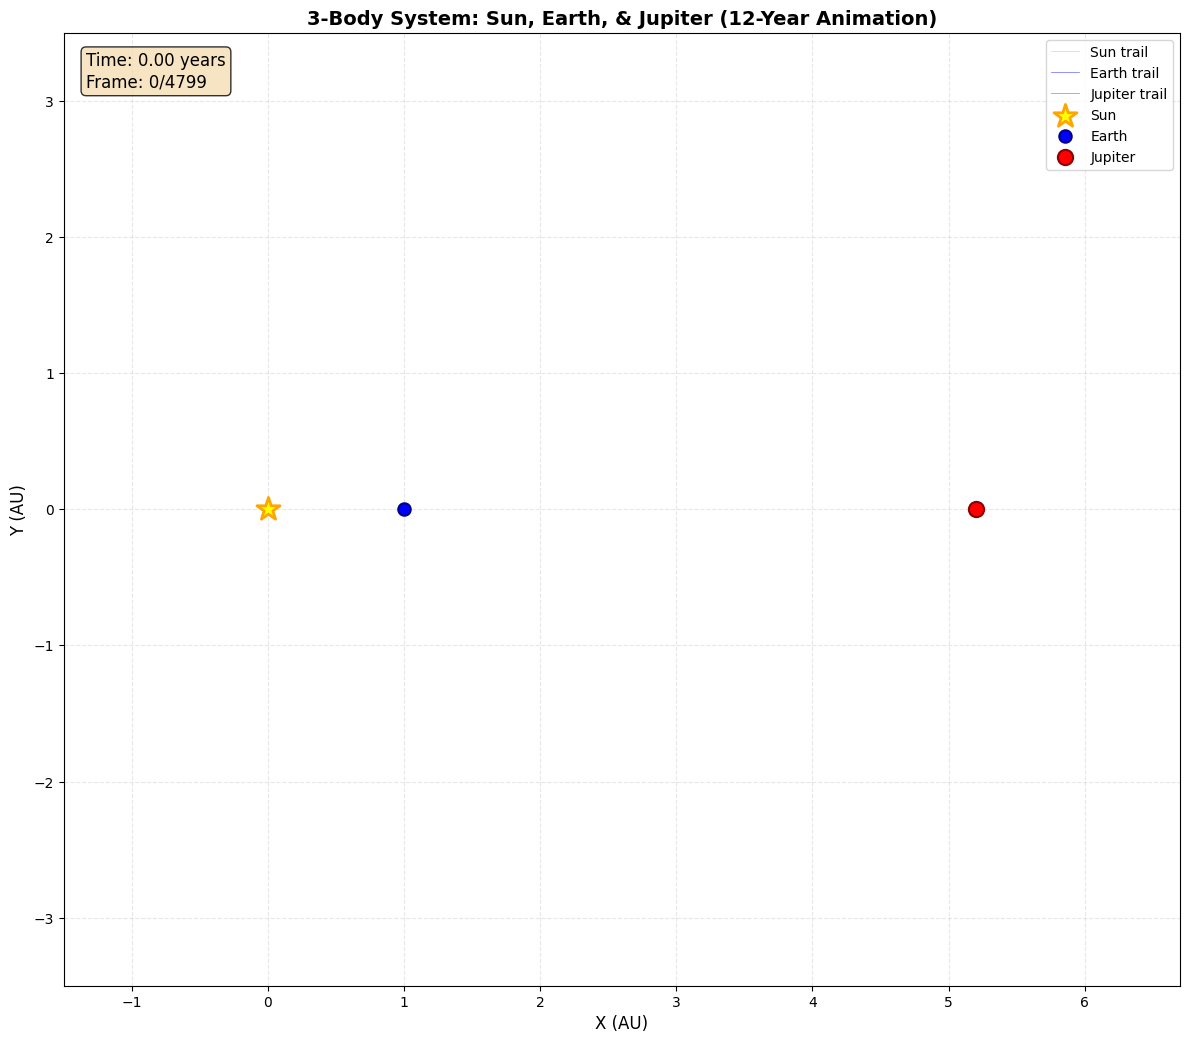

Animation complete! Showing 2400 frames at ~20.0 fps


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Circle
from scipy.integrate import solve_ivp

# --- 1. Physical Constants (High Precision) ---
G = 4 * np.pi**2
M_sun = 1.0
M_earth = 3.003e-6  
M_jup = 0.001       

# --- 2. Three-Body Equations of Motion ---
def three_body_equations(t, y):
    """
    State vector: [x_sun, y_sun, x_earth, y_earth, x_jup, y_jup, 
                   vx_sun, vy_sun, vx_earth, vy_earth, vx_jup, vy_jup]
    """
    x1, y1, x2, y2, x3, y3, vx1, vy1, vx2, vy2, vx3, vy3 = y
    
    # Distance vectors (squared and cubed)
    dx12, dy12 = x2 - x1, y2 - y1
    r12_sq = dx12**2 + dy12**2
    r12_3 = r12_sq**1.5
    
    dx13, dy13 = x3 - x1, y3 - y1
    r13_sq = dx13**2 + dy13**2
    r13_3 = r13_sq**1.5
    
    dx23, dy23 = x3 - x2, y3 - y2
    r23_sq = dx23**2 + dy23**2
    r23_3 = r23_sq**1.5
    
    # Accelerations: F = ma, a = Sum(G*m/r^2)
    # Sun: pulled by Earth and Jupiter
    dvx1 = G * M_earth * dx12 / r12_3 + G * M_jup * dx13 / r13_3
    dvy1 = G * M_earth * dy12 / r12_3 + G * M_jup * dy13 / r13_3
    
    # Earth: pulled by Sun and Jupiter
    dvx2 = -G * M_sun * dx12 / r12_3 + G * M_jup * dx23 / r23_3
    dvy2 = -G * M_sun * dy12 / r12_3 + G * M_jup * dy23 / r23_3
    
    # Jupiter: pulled by Sun and Earth
    dvx3 = -G * M_sun * dx13 / r13_3 - G * M_earth * dx23 / r23_3
    dvy3 = -G * M_sun * dy13 / r13_3 - G * M_earth * dy23 / r23_3
    
    return [vx1, vy1, vx2, vy2, vx3, vy3, dvx1, dvy1, dvx2, dvy2, dvx3, dvy3]

# --- 3. Initial Conditions ---
# Sun at center, initially at rest
sun_pos = [0.0, 0.0]
sun_vel = [0.0, 0.0]

# Earth at 1 AU with circular orbit velocity
earth_pos = [1.0, 0.0]
earth_vel = [0.0, 2 * np.pi]  # v = sqrt(GM/r) with G=4π², M=1, r=1

# Jupiter at 5.2 AU with circular orbit velocity
jup_pos = [5.2, 0.0]
jup_vel = [0.0, np.sqrt(G * M_sun / 5.2)]

y0 = sun_pos + earth_pos + jup_pos + sun_vel + earth_vel + jup_vel

# --- 4. Integrate with High Precision ---
t_span = (0, 12.0)  # 12 Earth years
# More points for smoother animation
t_eval = np.linspace(0, 12.0, 4800)  # ~400 states per year, ~33 per month

print("Integrating 3-body system with high precision (RK45, atol=1e-10, rtol=1e-10)...")
solution = solve_ivp(three_body_equations, t_span, y0, method='RK45', 
                     t_eval=t_eval, rtol=1e-10, atol=1e-10, dense_output=True)
print(f"Integration complete! {len(solution.t)} time steps generated.")

# Extract trajectories
x_sun = solution.y[0]
y_sun = solution.y[1]
x_earth = solution.y[2]
y_earth = solution.y[3]
x_jup = solution.y[4]
y_jup = solution.y[5]
times = solution.t

# --- 5. Create Animation ---
fig, ax = plt.subplots(figsize=(12, 12))

# Set up the plot limits with some margin
margin = 1.5
ax.set_xlim(-margin, 5.2 + margin)
ax.set_ylim(-3.5, 3.5)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_xlabel('X (AU)', fontsize=12)
ax.set_ylabel('Y (AU)', fontsize=12)
ax.set_title('3-Body System: Sun, Earth, & Jupiter (12-Year Animation)', fontsize=14, fontweight='bold')

# Create line objects for trails
line_sun, = ax.plot([], [], 'y-', lw=0.5, alpha=0.5, label='Sun trail')
line_earth, = ax.plot([], [], 'b-', lw=0.5, alpha=0.6, label='Earth trail')
line_jup, = ax.plot([], [], 'r-', lw=0.5, alpha=0.6, label='Jupiter trail')

# Create scatter objects for current positions
scatter_sun = ax.scatter([], [], s=300, c='yellow', marker='*', edgecolor='orange', linewidth=2, label='Sun', zorder=5)
scatter_earth = ax.scatter([], [], s=80, c='blue', marker='o', edgecolor='darkblue', linewidth=1.5, label='Earth', zorder=4)
scatter_jup = ax.scatter([], [], s=120, c='red', marker='o', edgecolor='darkred', linewidth=1.5, label='Jupiter', zorder=4)

# Text for time display
time_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                   fontsize=12, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Legend
ax.legend(loc='upper right', fontsize=10)

# Trail length (how many history points to show)
trail_length = 120  # ~12 months of history at our time resolution

def update(frame):
    """Update function for animation."""
    # Ensure we don't go out of bounds
    frame = min(frame, len(times) - 1)
    
    # Get current positions
    current_sun_x = x_sun[frame]
    current_sun_y = y_sun[frame]
    current_earth_x = x_earth[frame]
    current_earth_y = y_earth[frame]
    current_jup_x = x_jup[frame]
    current_jup_y = y_jup[frame]
    
    # Determine trail start
    trail_start = max(0, frame - trail_length)
    
    # Update trails
    line_sun.set_data(x_sun[trail_start:frame+1], y_sun[trail_start:frame+1])
    line_earth.set_data(x_earth[trail_start:frame+1], y_earth[trail_start:frame+1])
    line_jup.set_data(x_jup[trail_start:frame+1], y_jup[trail_start:frame+1])
    
    # Update current positions
    scatter_sun.set_offsets([[current_sun_x, current_sun_y]])
    scatter_earth.set_offsets([[current_earth_x, current_earth_y]])
    scatter_jup.set_offsets([[current_jup_x, current_jup_y]])
    
    # Update time display
    current_time = times[frame]
    time_text.set_text(f'Time: {current_time:.2f} years\nFrame: {frame}/{len(times)-1}')
    
    return line_sun, line_earth, line_jup, scatter_sun, scatter_earth, scatter_jup, time_text

# Create animation
# Use every 2nd frame for smoother playback (reduces computation)
frames = list(range(0, len(times), 2))
anim = animation.FuncAnimation(fig, update, frames=frames, 
                              interval=50, blit=True, repeat=True)

plt.tight_layout()
plt.show()

print(f"Animation complete! Showing {len(frames)} frames at ~{1000/50} fps")


Computing high-precision 3-body trajectory...


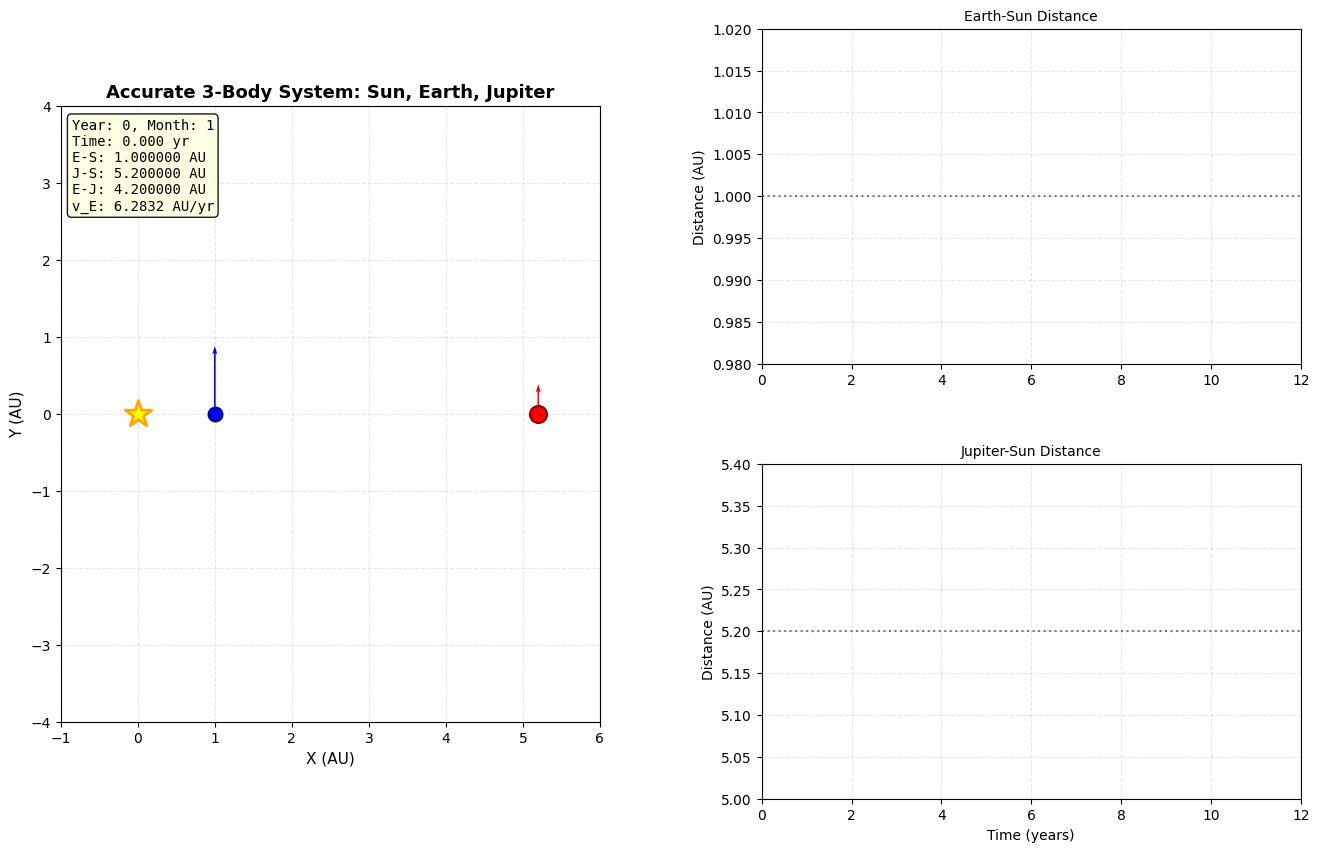

✓ High-precision animation complete (2400 frames, 4800 integration steps)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.integrate import solve_ivp

# --- High-Accuracy 3-Body Animation with Orbital Metrics ---

# Physical Constants
G = 4 * np.pi**2
M_sun = 100
M_earth = 3.003e-6  
M_jup = 1.0

def three_body_equations(t, y):
    """Differential equations for 3-body system."""
    x1, y1, x2, y2, x3, y3, vx1, vy1, vx2, vy2, vx3, vy3 = y
    
    dx12, dy12 = x2 - x1, y2 - y1
    r12_3 = (dx12**2 + dy12**2)**1.5
    
    dx13, dy13 = x3 - x1, y3 - y1
    r13_3 = (dx13**2 + dy13**2)**1.5
    
    dx23, dy23 = x3 - x2, y3 - y2
    r23_3 = (dx23**2 + dy23**2)**1.5
    
    dvx1 = G * M_earth * dx12 / r12_3 + G * M_jup * dx13 / r13_3
    dvy1 = G * M_earth * dy12 / r12_3 + G * M_jup * dy13 / r13_3
    
    dvx2 = -G * M_sun * dx12 / r12_3 + G * M_jup * dx23 / r23_3
    dvy2 = -G * M_sun * dy12 / r12_3 + G * M_jup * dy23 / r23_3
    
    dvx3 = -G * M_sun * dx13 / r13_3 - G * M_earth * dx23 / r23_3
    dvy3 = -G * M_sun * dy13 / r13_3 - G * M_earth * dy23 / r23_3
    
    return [vx1, vy1, vx2, vy2, vx3, vy3, dvx1, dvy1, dvx2, dvy2, dvx3, dvy3]

# Initial conditions
y0 = [0.0, 0.0, 1.0, 0.0, 5.2, 0.0, 0.0, 0.0, 0.0, 2*np.pi, 0.0, np.sqrt(G*M_sun/5.2)]

# Integrate with maximum precision
t_span = (0, 12.0)
t_eval = np.linspace(0, 12.0, 4800)

print("Computing high-precision 3-body trajectory...")
solution = solve_ivp(three_body_equations, t_span, y0, method='RK45', 
                     t_eval=t_eval, rtol=1e-11, atol=1e-11, dense_output=True)

x_sun, y_sun = solution.y[0], solution.y[1]
x_earth, y_earth = solution.y[2], solution.y[3]
x_jup, y_jup = solution.y[4], solution.y[5]
vx_sun, vy_sun = solution.y[6], solution.y[7]
vx_earth, vy_earth = solution.y[8], solution.y[9]
vx_jup, vy_jup = solution.y[10], solution.y[11]
times = solution.t

# Calculate orbital metrics
def calc_distance(x1, y1, x2, y2):
    return np.sqrt((x2-x1)**2 + (y2-y1)**2)

dist_earth_sun = calc_distance(x_sun, y_sun, x_earth, y_earth)
dist_jup_sun = calc_distance(x_sun, y_sun, x_jup, y_jup)
dist_earth_jup = calc_distance(x_earth, y_earth, x_jup, y_jup)

# Create figure with subplots
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

ax_main = fig.add_subplot(gs[0:2, 0])  # Main orbital plot (large)
ax_dist_es = fig.add_subplot(gs[0, 1])  # Earth-Sun distance
ax_dist_js = fig.add_subplot(gs[1, 1])  # Jupiter-Sun distance

# Main orbital plot setup
ax_main.set_xlim(-1, 6)
ax_main.set_ylim(-4, 4)
ax_main.set_aspect('equal')
ax_main.grid(True, linestyle='--', alpha=0.3)
ax_main.set_xlabel('X (AU)', fontsize=11)
ax_main.set_ylabel('Y (AU)', fontsize=11)
ax_main.set_title('Accurate 3-Body System: Sun, Earth, Jupiter', fontsize=13, fontweight='bold')

# Trails
line_sun, = ax_main.plot([], [], 'y-', lw=0.4, alpha=0.4)
line_earth, = ax_main.plot([], [], 'b-', lw=0.4, alpha=0.5)
line_jup, = ax_main.plot([], [], 'r-', lw=0.4, alpha=0.5)

# Current positions
scatter_sun = ax_main.scatter([], [], s=400, c='yellow', marker='*', edgecolor='orange', linewidth=2, zorder=5)
scatter_earth = ax_main.scatter([], [], s=100, c='blue', marker='o', edgecolor='darkblue', linewidth=1.5, zorder=4)
scatter_jup = ax_main.scatter([], [], s=150, c='red', marker='o', edgecolor='darkred', linewidth=1.5, zorder=4)

# Velocity vectors
quiv_sun = ax_main.quiver([], [], [], [], scale=15, width=0.003, color='orange', zorder=3)
quiv_earth = ax_main.quiver([], [], [], [], scale=15, width=0.003, color='blue', zorder=3)
quiv_jup = ax_main.quiver([], [], [], [], scale=15, width=0.003, color='red', zorder=3)

# Distance plots
ax_dist_es.set_ylabel('Distance (AU)', fontsize=10)
ax_dist_es.set_title('Earth-Sun Distance', fontsize=10)
ax_dist_es.grid(True, linestyle='--', alpha=0.3)
ax_dist_es.axhline(y=1.0, color='k', linestyle=':', alpha=0.5, label='1 AU')
line_dist_es, = ax_dist_es.plot([], [], 'b-', lw=2)
ax_dist_es.set_xlim(0, 12)
ax_dist_es.set_ylim(0.98, 1.02)

ax_dist_js.set_xlabel('Time (years)', fontsize=10)
ax_dist_js.set_ylabel('Distance (AU)', fontsize=10)
ax_dist_js.set_title('Jupiter-Sun Distance', fontsize=10)
ax_dist_js.grid(True, linestyle='--', alpha=0.3)
ax_dist_js.axhline(y=5.2, color='k', linestyle=':', alpha=0.5, label='5.2 AU')
line_dist_js, = ax_dist_js.plot([], [], 'r-', lw=2)
ax_dist_js.set_xlim(0, 12)
ax_dist_js.set_ylim(5.0, 5.4)

# Text box
info_text = ax_main.text(0.02, 0.98, '', transform=ax_main.transAxes,
                        fontsize=10, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9),
                        family='monospace')

trail_length = 150

def update(frame):
    frame = min(frame, len(times) - 1)
    trail_start = max(0, frame - trail_length)
    
    # Update main orbital plot
    line_sun.set_data(x_sun[trail_start:frame+1], y_sun[trail_start:frame+1])
    line_earth.set_data(x_earth[trail_start:frame+1], y_earth[trail_start:frame+1])
    line_jup.set_data(x_jup[trail_start:frame+1], y_jup[trail_start:frame+1])
    
    scatter_sun.set_offsets([[x_sun[frame], y_sun[frame]]])
    scatter_earth.set_offsets([[x_earth[frame], y_earth[frame]]])
    scatter_jup.set_offsets([[x_jup[frame], y_jup[frame]]])
    
    # Velocity vectors (scaled for visibility)
    vel_scale = 0.3
    quiv_sun.set_offsets([[x_sun[frame], y_sun[frame]]])
    quiv_sun.set_UVC(vx_sun[frame]*vel_scale, vy_sun[frame]*vel_scale)
    
    quiv_earth.set_offsets([[x_earth[frame], y_earth[frame]]])
    quiv_earth.set_UVC(vx_earth[frame]*vel_scale, vy_earth[frame]*vel_scale)
    
    quiv_jup.set_offsets([[x_jup[frame], y_jup[frame]]])
    quiv_jup.set_UVC(vx_jup[frame]*vel_scale, vy_jup[frame]*vel_scale)
    
    # Distance plots
    t_plot = times[:frame+1]
    line_dist_es.set_data(t_plot, dist_earth_sun[:frame+1])
    line_dist_js.set_data(t_plot, dist_jup_sun[:frame+1])
    
    # Info text
    current_time = times[frame]
    year = int(current_time)
    month = int((current_time % 1) * 12) + 1
    
    info_text.set_text(f'''Year: {year}, Month: {month}
Time: {current_time:.3f} yr
E-S: {dist_earth_sun[frame]:.6f} AU
J-S: {dist_jup_sun[frame]:.6f} AU
E-J: {dist_earth_jup[frame]:.6f} AU
v_E: {np.sqrt(vx_earth[frame]**2 + vy_earth[frame]**2):.4f} AU/yr''')
    
    return (line_sun, line_earth, line_jup, scatter_sun, scatter_earth, scatter_jup, 
            quiv_sun, quiv_earth, quiv_jup, line_dist_es, line_dist_js, info_text)

frames = list(range(0, len(times), 2))
anim = animation.FuncAnimation(fig, update, frames=frames,
                              interval=50, blit=True, repeat=True)

plt.show()

print(f"High-precision animation complete ({len(frames)} frames, 4800 integration steps)")


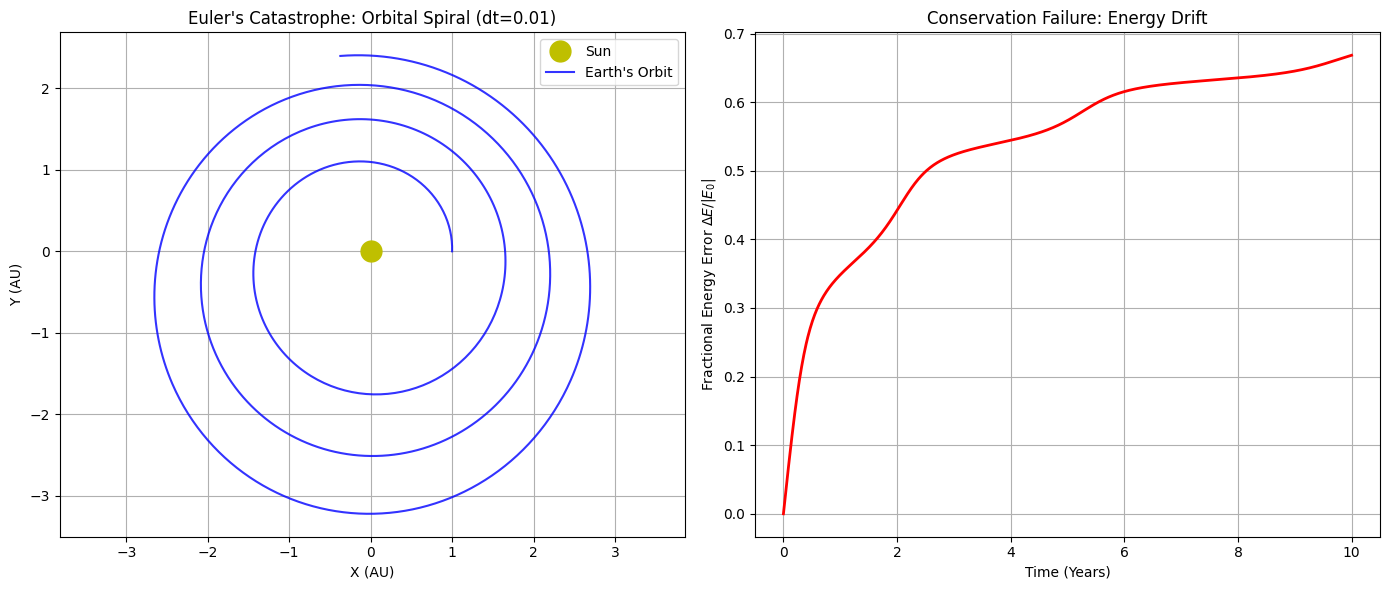

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Physical Constants
G = 4 * np.pi**2
M_sun = 1.0
M_earth = 3.003e-6

# 2. Manual Euler Method Implementation
def euler_step(y, dt):
    """
    Takes a single time step using the first-order Euler method.
    y = [x_sun, y_sun, x_earth, y_earth, vx_sun, vy_sun, vx_earth, vy_earth]
    """
    x1, y1, x2, y2, vx1, vy1, vx2, vy2 = y
    
    # Calculate distances and accelerations
    dx = x2 - x1
    dy = y2 - y1
    r = np.sqrt(dx**2 + dy**2)
    r3 = r**3
    
    ax1 = G * M_earth * dx / r3
    ay1 = G * M_earth * dy / r3
    ax2 = -G * M_sun * dx / r3
    ay2 = -G * M_sun * dy / r3
    
    # Update Positions (Using OLD velocities)
    new_x1 = x1 + vx1 * dt
    new_y1 = y1 + vy1 * dt
    new_x2 = x2 + vx2 * dt
    new_y2 = y2 + vy2 * dt
    
    # Update Velocities (Using OLD accelerations)
    new_vx1 = vx1 + ax1 * dt
    new_vy1 = vy1 + ay1 * dt
    new_vx2 = vx2 + ax2 * dt
    new_vy2 = vy2 + ay2 * dt
    
    return np.array([new_x1, new_y1, new_x2, new_y2, new_vx1, new_vy1, new_vx2, new_vy2])

# 3. Energy Calculation Function
def calculate_total_energy(y):
    x1, y1, x2, y2, vx1, vy1, vx2, vy2 = y
    
    # Kinetic Energy: 1/2 m v^2
    ke_sun = 0.5 * M_sun * (vx1**2 + vy1**2)
    ke_earth = 0.5 * M_earth * (vx2**2 + vy2**2)
    
    # Potential Energy: -G M m / r
    r = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    pe = -G * M_sun * M_earth / r
    
    return ke_sun + ke_earth + pe

# 4. Simulation Setup
dt = 0.01  # A reasonably small time step (1/100th of a year)
years = 10.0
n_steps = int(years / dt)

# Initial conditions (Circular orbit)
y = np.array([0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 2 * np.pi])

# Arrays to store history
history_x = np.zeros(n_steps)
history_y = np.zeros(n_steps)
history_E = np.zeros(n_steps)
time_array = np.linspace(0, years, n_steps)

# 5. Run the Euler Loop
for i in range(n_steps):
    history_x[i] = y[2] # Earth X
    history_y[i] = y[3] # Earth Y
    history_E[i] = calculate_total_energy(y)
    
    y = euler_step(y, dt)

# 6. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: The Outward Spiral
ax1.plot(0, 0, 'yo', markersize=15, label="Sun")
ax1.plot(history_x, history_y, 'b-', alpha=0.8, label="Earth's Orbit")
ax1.set_title(f"Euler's Catastrophe: Orbital Spiral (dt={dt})")
ax1.set_xlabel("X (AU)")
ax1.set_ylabel("Y (AU)")
ax1.axis('equal')
ax1.legend()
ax1.grid(True)

# Plot 2: The Energy Drift
# We calculate the fractional change in energy: (E - E0) / |E0|
fractional_energy_error = (history_E - history_E[0]) / abs(history_E[0])

ax2.plot(time_array, fractional_energy_error, 'r-', lw=2)
ax2.set_title("Conservation Failure: Energy Drift")
ax2.set_xlabel("Time (Years)")
ax2.set_ylabel("Fractional Energy Error $\Delta E / |E_0|$")
ax2.grid(True)

plt.tight_layout()
plt.show()